<a href="https://colab.research.google.com/github/Pritamq/Mini-Edgar-Allan-Poe/blob/main/mini_edgar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Building & Training a Modern LLM
## From scratch — RMSNorm, SwiGLU, RoPE, GQA



## Section 0: Setup

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import math
import time
import os

#checking if the device has a gpu or not
device = "cuda" if torch.cuda.is_available() else "cpu"
# macbook : "mps"
print(f"Using device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cpu


## Section 0.1: Download & Prepare Edgar

Byte Pair Encoding





In [3]:
from tokenizers import ByteLevelBPETokenizer
import os

# 1. Train the Tokenizer
tokenizer = ByteLevelBPETokenizer()
tokenizer.train(files=["edgar_allan_poe_corpus.txt"], vocab_size=5000, min_frequency=2)

# 2. Save the files to the current directory
tokenizer.save_model(".")

# 3. Load the tokenizer back into memory from the saved files
# This ensures it is initialized as a ByteLevelBPETokenizer object
tokenizer = ByteLevelBPETokenizer(
    "vocab.json",
    "merges.txt"
)

print(f"Tokenizer loaded! Vocab size: {tokenizer.get_vocab_size()}")

def decode(indices):
    return tokenizer.decode(indices)

ModuleNotFoundError: No module named 'tokenizers'

In [ ]:
# Train/val split (90/10)
import torch

#Using HF tokenizer to get the integer ids

with open("edgar_allan_poe_corpus.txt", "r", encoding="utf-8") as f:
    text = f.read()
encoded_data=tokenizer.encode(text).ids

# Train / Val Split (90/10)
data = torch.tensor(encoded_data, dtype=torch.long)
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

print(f"Training tokens:   {len(train_data):,}")
print(f"Test tokens: {len(val_data):,}")

Training tokens:   262,781
Test tokens: 29,198


In [ ]:
# Batching: grab random chunks of text
# ==============================================================================
# DATA BATCHING, TEACHER FORCING, AND PARALLEL TRAINING PIPELINE
# ==============================================================================
# CONCEPTUAL BREAKDOWN (How the model learns):
# 1. CHUNKING & BATCHING:
#    Instead of reading sequentially, we pick 'batch_size' number of completely
#    random starting positions ('ix') across the 1-million+ character dataset.
#    From each position, we slice a window of 'context_length' characters.
#    Processing these multiple chunks in parallel on the GPU saves massive time.
#
# 2. TARGET SHIFTING & TEACHER FORCING:
#    The Targets (y) are identical to the Inputs (x) but shifted right by 1 character.
#    This structure means a single 50-character chunk gives the model 50 distinct
#    opportunities to practice predicting the "next" character. During this
#    process, the model is "Teacher Fed"—even if it guesses incorrectly at step 5,
#    we force-feed it the correct text at step 6 so the sequence doesn't derail.
#
# 3. THE RAINDROP EFFECT (STOCHASTIC SAMPLING):
#    Because one batch only covers a tiny fraction of the data (e.g., 8 x 50 = 400 chars),
#    we loop this function millions of times (Iterations/Epochs). Like raindrops
#    eventually soaking a sidewalk, these overlapping random slices guarantee that
#    every character is covered multiple times from different contextual angles.
#    This repetition acts as "revision," radically boosting the model's accuracy.
# ==============================================================================


def get_batch(split, batch_size, context_length):
    d = train_data if split == "train" else val_data
    ix = torch.randint(len(d) - context_length, (batch_size,))
    x = torch.stack([d[i:i+context_length] for i in ix])
    y = torch.stack([d[i+1:i+context_length+1] for i in ix])
    return x.to(device), y.to(device)

# Quick test
xb, yb = get_batch("train", batch_size=4, context_length=8)
print(f"Input shape:  {xb.shape}  (batch_size x context_length)")
print(f"Target shape: {yb.shape}")
print(f"\nExample (first sequence):")
print(f"  Input:  {decode(xb[0].tolist())!r}")
print(f"  Target: {decode(yb[0].tolist())!r}")
print(f"  (Target is input shifted by 1 character)")

Input shape:  torch.Size([4, 8])  (batch_size x context_length)
Target shape: torch.Size([4, 8])

Example (first sequence):
  Input:  's lay still in heaven, Morella'
  Target: ' lay still in heaven, Morella called'
  (Target is input shifted by 1 character)


---
# Section 1: RMSNorm


In [ ]:
class RMSNorm(nn.Module):
    """
    Root Mean Square Layer Normalization.

    Simpler than LayerNorm:
    - No mean subtraction
    - No bias/shift parameter
    - Just: x / RMS(x) * learnable_scale(a set of learnable parameters that allows the model to scale the numbers up or down if it decides a specific feature needs to be louder or quieter.)
    """
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))

    def forward(self, x):
        rms = torch.sqrt(x.pow(2).mean(dim=-1, keepdim=True) + self.eps)
        return (x / rms) * self.weight

# We will also use Dropout throughout the model.
# Dropout randomly zeroes some values during training,
# forcing the model to not rely on any single feature.
# This prevents memorization (overfitting).
# In this we randomly bench 20% of the neurons randomly at every step of prediction so that over millions of iteraions every neuron has learned
DROPOUT = 0.2 #tried 0.1 as well don't work well


# --- Demo ---
# 2 is batch number
# 4 id the context limit
# 8 is the dimension of the embedding
demo_x = torch.randn(2, 4, 8)
norm = RMSNorm(8)
demo_out = norm(demo_x)

print("RMSNorm demo:")
print(f"  Input  - mean: {demo_x.mean():.3f}, std: {demo_x.std():.3f}")
print(f"  Output - mean: {demo_out.mean():.3f}, std: {demo_out.std():.3f}")
print(f"  Input range:  [{demo_x.min():.3f}, {demo_x.max():.3f}]")
print(f"  Output range: [{demo_out.min():.3f}, {demo_out.max():.3f}]")
print(f"\n  Parameters: just a scale vector of size {norm.weight.shape}")

RMSNorm demo:
  Input  - mean: -0.171, std: 0.980
  Output - mean: -0.203, std: 0.987
  Input range:  [-2.684, 2.222]
  Output range: [-2.471, 1.923]

  Parameters: just a scale vector of size torch.Size([8])


---
# Section 2: Rotary Positional Embeddings (RoPE)



In [ ]:
def precompute_rope_freqs(head_dim, max_seq_len, base=10000.0):
    """
    Precompute cosine and sine tables for RoPE.

    Each pair of dimensions gets a different rotation frequency.
    Low dims  -> fast rotation -> short-range patterns
    High dims -> slow rotation -> long-range patterns
    """
    freqs = 1.0 / (base ** (torch.arange(0, head_dim, 2).float() / head_dim))
    positions = torch.arange(max_seq_len).float()
    angles = torch.outer(positions, freqs)  # [max_seq_len, head_dim // 2]
    return torch.cos(angles), torch.sin(angles)


def apply_rope(x, cos, sin):
    """
    Apply rotary embeddings to a tensor.

    x: [batch, n_heads, seq_len, head_dim]
    cos, sin: [seq_len, head_dim // 2]

    For each pair of dimensions (2i, 2i+1):
      rotated_2i   = x_2i * cos - x_2i+1 * sin
      rotated_2i+1 = x_2i * sin + x_2i+1 * cos
    """
    seq_len = x.shape[2]
    cos = cos[:seq_len].unsqueeze(0).unsqueeze(0)  # [1, 1, seq, hd//2]
    sin = sin[:seq_len].unsqueeze(0).unsqueeze(0)

    x1 = x[..., ::2]   # even dims
    x2 = x[..., 1::2]  # odd dims

    out1 = x1 * cos - x2 * sin
    out2 = x1 * sin + x2 * cos

    return torch.stack([out1, out2], dim=-1).flatten(-2)

---
# Section 3: Grouped Query Attention (GQA)



In [ ]:
def repeat_kv(x, n_rep):
    """
    Repeat KV heads to match the number of query heads.
    x: [batch, n_kv_heads, seq_len, head_dim]
    Returns: [batch, n_kv_heads * n_rep, seq_len, head_dim]
    """
    if n_rep == 1:
        return x
    b, n_kv, seq, hd = x.shape
    return (x[:, :, None, :, :]
            .expand(b, n_kv, n_rep, seq, hd)
            .reshape(b, n_kv * n_rep, seq, hd))


class GroupedQueryAttention(nn.Module):
    """
    Grouped Query Attention with RoPE.
    n_heads query heads, n_kv_heads key/value heads.
    Groups of (n_heads // n_kv_heads) query heads share one KV pair.
    """
    def __init__(self, d_model, n_heads, n_kv_heads):
        super().__init__()
        assert d_model % n_heads == 0
        assert n_heads % n_kv_heads == 0

        self.n_heads = n_heads
        self.n_kv_heads = n_kv_heads
        self.n_rep = n_heads // n_kv_heads
        self.head_dim = d_model // n_heads

        self.q_proj = nn.Linear(d_model, n_heads * self.head_dim, bias=False)
        self.k_proj = nn.Linear(d_model, n_kv_heads * self.head_dim, bias=False)
        self.v_proj = nn.Linear(d_model, n_kv_heads * self.head_dim, bias=False)
        self.o_proj = nn.Linear(n_heads * self.head_dim, d_model, bias=False)

    def forward(self, x, rope_cos, rope_sin):
        b, seq, _ = x.shape

        # Project Q, K, V
        q = self.q_proj(x)
        k = self.k_proj(x)
        v = self.v_proj(x)

        # Reshape into heads
        q = q.view(b, seq, self.n_heads, self.head_dim).transpose(1, 2)
        k = k.view(b, seq, self.n_kv_heads, self.head_dim).transpose(1, 2)
        v = v.view(b, seq, self.n_kv_heads, self.head_dim).transpose(1, 2)

        # Apply RoPE to Q and K (not V!)
        q = apply_rope(q, rope_cos, rope_sin)
        k = apply_rope(k, rope_cos, rope_sin)

        # Repeat KV heads to match Q heads
        k = repeat_kv(k, self.n_rep)
        v = repeat_kv(v, self.n_rep)

        # Scaled dot-product attention with causal mask
        scale = 1.0 / math.sqrt(self.head_dim)
        scores = (q @ k.transpose(-2, -1)) * scale

        mask = torch.triu(torch.ones(seq, seq, device=x.device), diagonal=1).bool()
        scores = scores.masked_fill(mask, float("-inf"))

        weights = F.softmax(scores, dim=-1)

        # Dropout on attention weights (regularization)
        weights = F.dropout(weights, p=DROPOUT, training=self.training)

        out = weights @ v

        # Merge heads and project
        out = out.transpose(1, 2).contiguous().view(b, seq, -1)
        return self.o_proj(out)

---
# Section 4: SwiGLU Feed-Forward Network



In [ ]:
class SwiGLU(nn.Module):
    """
    SwiGLU Feed-Forward Network.

    Two paths:
      gate: SiLU(x @ W_gate) - controls flow
      up:   x @ W_up         - carries information

    Combined: gate * up -> W_down

    SiLU(x) = x * sigmoid(x), a smooth version of ReLU.
    """
    def __init__(self, d_model, hidden_dim):
        super().__init__()
        self.w_gate = nn.Linear(d_model, hidden_dim, bias=False)
        self.w_up   = nn.Linear(d_model, hidden_dim, bias=False)
        self.w_down = nn.Linear(hidden_dim, d_model, bias=False)

    def forward(self, x):
        gate = F.silu(self.w_gate(x))
        up   = self.w_up(x)
        return F.dropout(self.w_down(gate * up), p=DROPOUT, training=self.training)

---
# Section 5: Assemble the Full Model

Now we wire everything together:
1. Token Embedding
2. N x Transformer Blocks (RMSNorm -> GQA -> Add -> RMSNorm -> SwiGLU -> Add)
3. Final RMSNorm -> Language Model Head

In [ ]:
class TransformerBlock(nn.Module):
    """
    One layer of a modern transformer.

    Pre-norm architecture:
      x -> RMSNorm -> GQA Attention -> + residual
      x -> RMSNorm -> SwiGLU FFN     -> + residual
    """
    def __init__(self, d_model, n_heads, n_kv_heads, ffn_hidden_dim):
        super().__init__()
        self.attn_norm = RMSNorm(d_model)
        self.attention = GroupedQueryAttention(d_model, n_heads, n_kv_heads)
        self.ffn_norm  = RMSNorm(d_model)
        self.ffn       = SwiGLU(d_model, ffn_hidden_dim)

    def forward(self, x, rope_cos, rope_sin):
        # Pre-norm -> Attention -> Residual
        x = x + self.attention(self.attn_norm(x), rope_cos, rope_sin)
        # Pre-norm -> FFN -> Residual
        x = x + self.ffn(self.ffn_norm(x))
        return x

In [ ]:

class MiniLLM(nn.Module):
    """
    A small but modern language model.

    Architecture: modern transformer with all 4 upgrades.
    Training objective: next character prediction.
    """
    def __init__(self, vocab_size, d_model, n_layers, n_heads, n_kv_heads,
                 ffn_hidden_dim, max_seq_len):
        super().__init__()

        self.d_model = d_model
        self.max_seq_len = max_seq_len

        # Token embedding (no positional embedding -- RoPE handles position)
        self.token_emb = nn.Embedding(vocab_size, d_model)

        # Transformer blocks
        self.layers = nn.ModuleList([
            TransformerBlock(d_model, n_heads, n_kv_heads, ffn_hidden_dim)
            for _ in range(n_layers)
        ])

        # Final norm and output head
        self.final_norm = RMSNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)

        # Weight tying: share embedding and output weights
        self.lm_head.weight = self.token_emb.weight

        # Precompute RoPE frequencies
        head_dim = d_model // n_heads
        rope_cos, rope_sin = precompute_rope_freqs(head_dim, max_seq_len)
        self.register_buffer("rope_cos", rope_cos)
        self.register_buffer("rope_sin", rope_sin)

        # Initialize weights
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        b, seq_len = idx.shape

        # Token embedding
        x = self.token_emb(idx)

        # Pass through transformer blocks
        for layer in self.layers:
            x = layer(x, self.rope_cos, self.rope_sin)

        # Final norm + project to vocabulary
        x = self.final_norm(x)
        logits = self.lm_head(x)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)),
                targets.view(-1)
            )

        return logits, loss

## 5.1: Create the model and inspect it

In [ ]:
# --- Model Configuration ---


config = {
    "vocab_size": tokenizer.get_vocab_size(),
    "d_model":        128,
    "n_layers":       2,
    "n_heads":        4,
    "n_kv_heads":     2,
    "ffn_hidden_dim": 340,
    "max_seq_len":    256,
}

model = MiniLLM(**config).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=" * 50)
print("  MODEL SUMMARY")
print("=" * 50)
print(f"  Vocabulary:      {config['vocab_size']}")
print(f"  Embedding dim:   {config['d_model']}")
print(f"  Layers:          {config['n_layers']}")
print(f"  Query heads:     {config['n_heads']}")
print(f"  KV heads:        {config['n_kv_heads']} (GQA ratio: {config['n_heads']//config['n_kv_heads']}:1)")
print(f"  FFN hidden dim:  {config['ffn_hidden_dim']}")
print(f"  Context length:  {config['max_seq_len']}")
print(f"  Head dim:        {config['d_model'] // config['n_heads']}")
print(f"{'=' * 50}")
print(f"  Total parameters:     {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Model size (approx):  {total_params * 4 / 1e6:.1f} MB (float32)")
print(f"{'=' * 50}")

  MODEL SUMMARY
  Vocabulary:      5000
  Embedding dim:   128
  Layers:          2
  Query heads:     4
  KV heads:        2 (GQA ratio: 2:1)
  FFN hidden dim:  340
  Context length:  256
  Head dim:        32
  Total parameters:     1,000,064
  Trainable parameters: 1,000,064
  Model size (approx):  4.0 MB (float32)



# Section 6: Training

Same training loop pattern from Class 2 — forward, loss, backward, step. The model inside is more sophisticated, but the dance is identical.

In [ ]:
# --- Training Hyperparameters ---
BATCH_SIZE = 64
CONTEXT_LEN = config["max_seq_len"]

LEARNING_RATE = 3e-4
MAX_STEPS = 1000

EVAL_INTERVAL = 100
EVAL_STEPS = 20
LOG_INTERVAL = 25

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=0.1
)

In [ ]:
@torch.no_grad()
def estimate_loss():
    """Estimate loss on train and val splits."""
    model.eval()
    out = {}
    for split in ["train", "val"]:
        losses = []
        for _ in range(EVAL_STEPS):
            xb, yb = get_batch(split, BATCH_SIZE, CONTEXT_LEN)
            _, loss = model(xb, yb)
            losses.append(loss.item())
        out[split] = sum(losses) / len(losses)
    model.train()
    return out

In [ ]:
# --- Training Loop ---
print("Starting training...")
print(f"  {MAX_STEPS} steps, batch_size={BATCH_SIZE}, context_len={CONTEXT_LEN}")
print(f"  Evaluating every {EVAL_INTERVAL} steps")
print("-" * 60)

train_losses = []
val_losses = []
step_log = []
start_time = time.time()

model.train()
for step in range(MAX_STEPS):
    xb, yb = get_batch("train", BATCH_SIZE, CONTEXT_LEN)

    logits, loss = model(xb, yb)

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    if step % LOG_INTERVAL == 0:
        elapsed = time.time() - start_time
        print(f"  Step {step:5d}/{MAX_STEPS} | Loss: {loss.item():.4f} | Time: {elapsed:.0f}s")

    if step % EVAL_INTERVAL == 0 or step == MAX_STEPS - 1:
        losses = estimate_loss()
        train_losses.append(losses["train"])
        val_losses.append(losses["val"])
        step_log.append(step)
        if step > 0:
            elapsed = time.time() - start_time
            steps_per_sec = step / elapsed
            remaining = (MAX_STEPS - step) / steps_per_sec
            print(f"  >>> Eval @ step {step}: train={losses['train']:.4f}, val={losses['val']:.4f} | ~{remaining:.0f}s remaining")

total_time = time.time() - start_time
print("-" * 60)
print(f"Training complete! Total time: {total_time:.0f}s ({total_time/60:.1f} min)")
print(f"Final train loss: {train_losses[-1]:.4f}")
print(f"Final val loss:   {val_losses[-1]:.4f}")

Starting training...
  1000 steps, batch_size=64, context_len=256
  Evaluating every 100 steps
------------------------------------------------------------
  Step     0/1000 | Loss: 8.5368 | Time: 0s
  Step    25/1000 | Loss: 7.5637 | Time: 4s
  Step    50/1000 | Loss: 6.9601 | Time: 6s
  Step    75/1000 | Loss: 6.5712 | Time: 8s
  Step   100/1000 | Loss: 6.3343 | Time: 10s
  >>> Eval @ step 100: train=6.3238, val=6.3190 | ~104s remaining
  Step   125/1000 | Loss: 6.1186 | Time: 14s
  Step   150/1000 | Loss: 5.9382 | Time: 16s
  Step   175/1000 | Loss: 5.7947 | Time: 18s
  Step   200/1000 | Loss: 5.7449 | Time: 20s
  >>> Eval @ step 200: train=5.6821, val=5.7043 | ~87s remaining
  Step   225/1000 | Loss: 5.6331 | Time: 24s
  Step   250/1000 | Loss: 5.5632 | Time: 26s
  Step   275/1000 | Loss: 5.5088 | Time: 28s
  Step   300/1000 | Loss: 5.4303 | Time: 30s
  >>> Eval @ step 300: train=5.4064, val=5.4722 | ~74s remaining
  Step   325/1000 | Loss: 5.3506 | Time: 34s
  Step   350/1000 | Lo

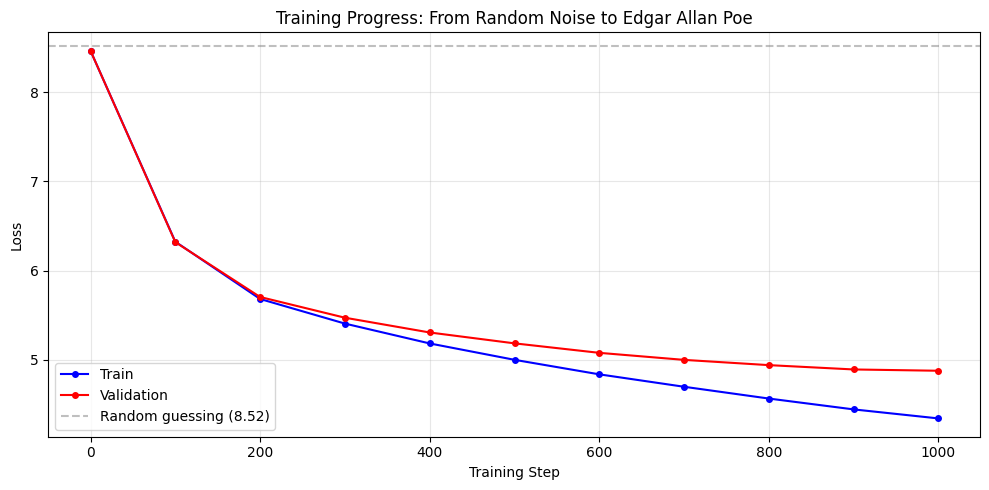

In [ ]:
# --- Plot Loss Curve ---
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(step_log, train_losses, "b-o", label="Train", markersize=4)
ax.plot(step_log, val_losses, "r-o", label="Validation", markersize=4)

random_loss = math.log(tokenizer.get_vocab_size())
ax.axhline(
    y=random_loss,
    color="gray",
    linestyle="--",
    alpha=0.5,
    label=f"Random guessing ({random_loss:.2f})"
)

ax.set_xlabel("Training Step")
ax.set_ylabel("Loss")
ax.set_title("Training Progress: From Random Noise to Edgar Allan Poe")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
# Section 7: Generate Text! 🎭

The payoff. We feed in a seed text, predict the next character, append it, and repeat. This is **autoregressive generation** — the same process ChatGPT uses, just at character level.

In [ ]:
@torch.no_grad()
def generate(model, prompt, max_new_tokens=500, temperature=0.8, top_k=50):
    model.eval()

    tokens = tokenizer.encode(prompt).ids
    tokens = torch.tensor(tokens, dtype=torch.long, device=device).unsqueeze(0)

    for _ in range(max_new_tokens):
        context = tokens[:, -config["max_seq_len"]:]
        logits, _ = model(context)

        logits = logits[:, -1, :] / temperature

        if top_k is not None:
            v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
            logits[logits < v[:, [-1]]] = -float("inf")

        probs = F.softmax(logits, dim=-1)
        next_token = torch.multinomial(probs, num_samples=1)
        tokens = torch.cat([tokens, next_token], dim=1)

    return tokenizer.decode(tokens[0].tolist())

In [ ]:
# --- Generate Poe-like text ---
prompt = "Love"

print("=" * 60)
print(f"  PROMPT: {prompt!r}")
print("=" * 60)

for temp in [0.4, 0.5, 0.6, 0.7]:
    print(f"\n{'_' * 60}")
    print(f"  Temperature = {temp}")
    print(f"{'_' * 60}")

    output = generate(
        model,
        prompt,
        max_new_tokens=150,
        temperature=temp,
        top_k=50
    )

    print(output)

  PROMPT: 'Love'

____________________________________________________________
  Temperature = 0.4
____________________________________________________________
Love, and the most remarkable of the gxxa, and the gee, and so far as to be sure, in the most important of the most perplexing of the room.
It was a man of the most important which I had been at the same time, and, in the most important portion of the earth's life.
The earth was not at the matter of the first instance, and the man was so doing.
The whole was also much of the most important character of the world, and the most important portion of the bounded body of the carvvalal nature.
"I am not," said I.
I had been a few of his own.
I am not that

____________________________________________________________
  Temperature = 0.5
____________________________________________________________
Love, the pims, and my wife, and the body of the floor, and the most most thoroughly thrown into the most important air of the most remote an